## HEHE KITA MAIN DATA SEK

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
plt.style.use('ggplot')
import random
import numpy as np

from warnings import filterwarnings
filterwarnings("ignore")

### CREATE USER DATA

In [2]:
users_data = []
number_users = 5000

for i in range(number_users):
    monthly_income = np.random.lognormal(mean=14, sigma=0.7)
    credit_score = np.random.normal(loc=0.6, scale=0.15)
    credit_score = np.clip(credit_score, 0, 1)
    
    users_data.append({
        "name": f"name-{i+1}",
        "age": random.randint(18, 45),
        "occupation": random.randint(0, 10),
        "monthly_income": int(monthly_income),
        "social_status": int(np.random.exponential(scale=1.2)),
        "location": random.randint(0, 5),
        "credit_score": credit_score,
    })

In [3]:
df = pd.DataFrame(users_data)
df

,name,age,occupation,monthly_income,social_status,location,credit_score
0,name-1,18,1,1769015,1,0,0.704261
1,name-2,43,0,1614331,0,0,0.437840
2,name-3,36,9,381323,0,1,0.537166
3,name-4,30,8,309477,1,0,0.529336
4,name-5,21,2,753841,3,1,0.436771
...,...,...,...,...,...,...,...
4995,name-4996,21,2,635639,2,2,0.568472
4996,name-4997,26,5,951435,0,5,0.709981
4997,name-4998,25,10,978375,2,0,0.547010
4998,name-4999,30,10,3341422,0,0,0.698386


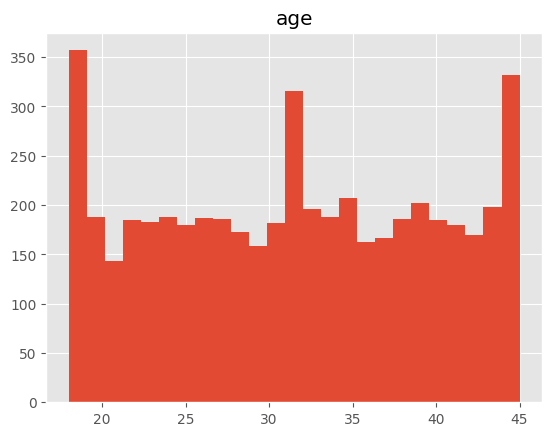

In [4]:
df.hist(column='age', bins=25)
plt.show()

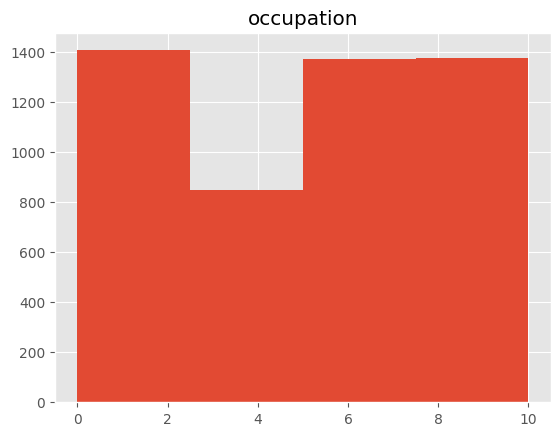

In [5]:
df.hist(column='occupation', bins=4)
plt.show()

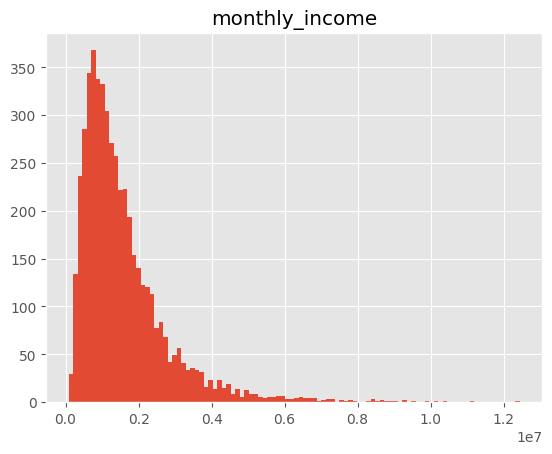

In [6]:
df.hist(column='monthly_income', bins=100)
plt.show()

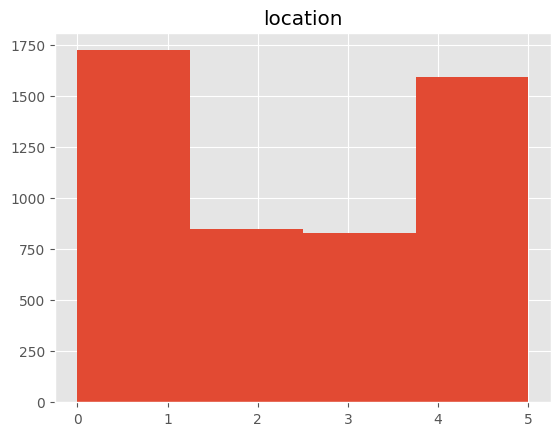

In [7]:
df.hist(column='location', bins=4)
plt.show()

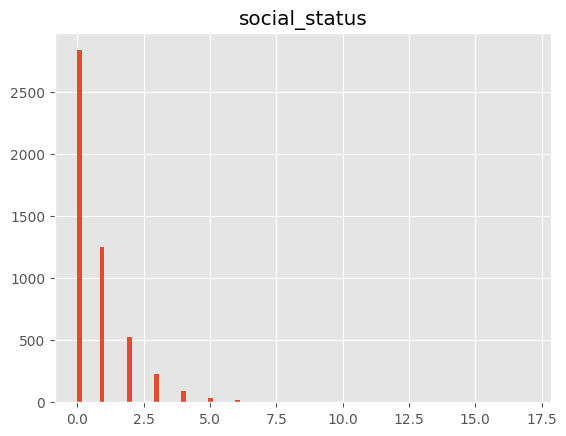

In [8]:
df.hist(column='social_status', bins=100)
plt.show()

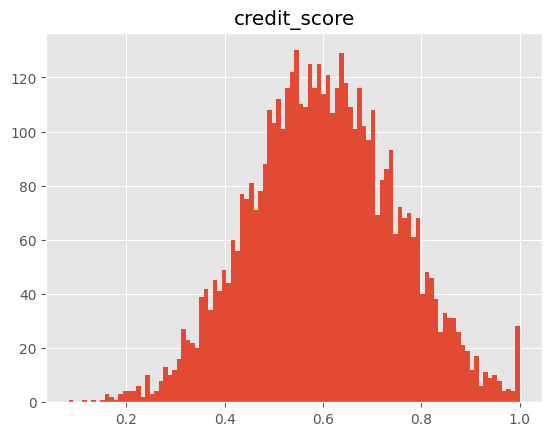

In [9]:
df.hist(column='credit_score', bins=100)
plt.show()

### CREATE USER HUB DATA BY HOW THEY RELATED EACH OTHER

In [10]:
user_hub = []
existing_relations = set()

for i in range(len(users_data)):
    for j in range(i + 1, len(users_data)):
        user_1 = users_data[i]
        user_2 = users_data[j]

        if abs(user_1['location'] - user_2['location']) < 2:

            if random.random() < 0.05:

                pair = tuple(sorted([user_1['name'], user_2['name']]))

                if pair not in existing_relations:
                    existing_relations.add(pair)

                    user_hub.append({
                        "user_1": pair[0],
                        "user_2": pair[1],
                        "related_kind": random.randint(1, 5)
                    })

In [11]:
pd.DataFrame(user_hub)

,user_1,user_2,related_kind
0,name-1,name-3,5
1,name-1,name-11,2
2,name-1,name-82,3
3,name-1,name-163,5
4,name-1,name-187,1
...,...,...,...
280032,name-4979,name-4991,5
280033,name-4981,name-4988,5
280034,name-4984,name-4999,3
280035,name-4988,name-4994,1


### CREATE USER ENGANGEMENT DATA BY HOW THE DO THEIR ACTIVITY

In [12]:
import random
import numpy as np
from collections import defaultdict
from datetime import datetime, timedelta

# -----------------------------------
# 1. Build adjacency map
# -----------------------------------
relation_map = defaultdict(dict)

for rel in user_hub:
    u1 = rel["user_1"]
    u2 = rel["user_2"]
    related_level = rel["related_kind"]
    
    relation_map[u1][u2] = related_level
    relation_map[u2][u1] = related_level


# -----------------------------------
# 2. Generate Activity Records
# -----------------------------------
activity_records = []

start_time = datetime.now()

for i in range(100):

    base_user = random.choice(users_data)["name"]
    participants = {base_user}

    if base_user in relation_map:
        for other_user, related_level in relation_map[base_user].items():

            join_prob = 0.05 + (related_level * 0.08)

            if random.random() < join_prob:
                participants.add(other_user)

    participants = list(participants)

    base_value = np.random.normal(loc=5_000_000, scale=2_000_000)

    value_creation = max(0, base_value * (1 + 0.3 * (len(participants) - 1)))

    activity_records.append({
        "user_names": participants,
        "activity": random.randint(0, 20),
        "value_creation": int(value_creation),
        "time_stamps": start_time + timedelta(minutes=i)
    })

In [13]:
activity_records_df = pd.DataFrame(activity_records)
activity_records_df

,user_names,activity,value_creation,time_stamps
0,"[name-4056, name-4412, name-3021, name-471, na...",17,72449350,2026-03-22 21:42:12.600060
1,"[name-4348, name-1389, name-4849, name-1998, n...",18,40654787,2026-03-22 21:43:12.600060
2,"[name-4801, name-15, name-2749, name-3213, nam...",1,51055868,2026-03-22 21:44:12.600060
3,"[name-2041, name-2665, name-2256, name-3721, n...",3,71377157,2026-03-22 21:45:12.600060
4,"[name-3137, name-2563, name-3965, name-530, na...",0,64561755,2026-03-22 21:46:12.600060
...,...,...,...,...
95,"[name-1780, name-4328, name-4826, name-2570, n...",18,55903399,2026-03-22 23:17:12.600060
96,"[name-1160, name-472, name-772, name-1468, nam...",14,71680653,2026-03-22 23:18:12.600060
97,"[name-4589, name-3450, name-4173, name-651, na...",12,67459215,2026-03-22 23:19:12.600060
98,"[name-2871, name-3425, name-261, name-3044, na...",15,24178136,2026-03-22 23:20:12.600060


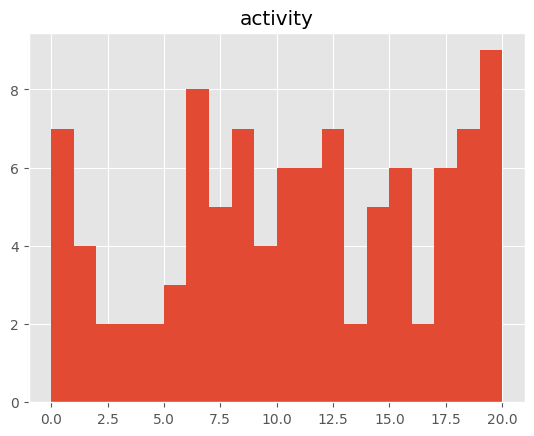

In [14]:
activity_records_df.hist(column='activity', bins=20)

plt.show()

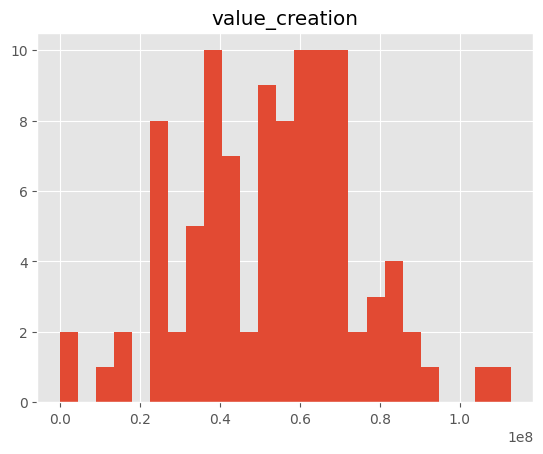

In [15]:
activity_records_df.hist(column='value_creation', bins=25)

plt.show()

### SAVE DATA

In [16]:
recorded_act = pd.DataFrame(activity_records)

recorded_act.to_csv("../datas/recorded-actifity.csv", index=False)

In [17]:
users_hub = pd.DataFrame(user_hub)

users_hub.to_csv("../datas/user-relation.csv", index=False)

In [18]:
users = pd.DataFrame(users_data)

users.to_csv("../datas/users.csv", index=False)

## Test Of using Data

In [19]:
actifity_data = pd.read_csv("../datas/recorded-actifity.csv")
user_data = pd.read_csv("../datas/users.csv")

### Activity Data

In [20]:
actifity_data.head()

,user_names,activity,value_creation,time_stamps
0,"['name-4056', 'name-4412', 'name-3021', 'name-...",17,72449350,2026-03-22 21:42:12.600060
1,"['name-4348', 'name-1389', 'name-4849', 'name-...",18,40654787,2026-03-22 21:43:12.600060
2,"['name-4801', 'name-15', 'name-2749', 'name-32...",1,51055868,2026-03-22 21:44:12.600060
3,"['name-2041', 'name-2665', 'name-2256', 'name-...",3,71377157,2026-03-22 21:45:12.600060
4,"['name-3137', 'name-2563', 'name-3965', 'name-...",0,64561755,2026-03-22 21:46:12.600060


In [21]:
print(f"max value of value_creation is {actifity_data['value_creation'].max()} and min value of value_creation is {actifity_data['value_creation'].min()}")

max value of value_creation is 112772384 and min value of value_creation is 0


In [22]:
print(f"max value of activity is {actifity_data['activity'].max()} and min value of activity is {actifity_data['activity'].min()}")

max value of activity is 20 and min value of activity is 0


In [23]:
adjency_dictionary = {
    "idx": [i for i in user_data['name'].to_list()]
}

for i in user_data['name']:
    adjency_dictionary[i] = [0] * len(user_data['name'].to_list())

In [24]:
adjency_dictionary_dataframe = pd.DataFrame(adjency_dictionary)

adjency_dictionary_dataframe.set_index("idx", inplace=True)

adjency_dictionary_dataframe.columns

Index(['name-1', 'name-2', 'name-3', 'name-4', 'name-5', 'name-6', 'name-7',
       'name-8', 'name-9', 'name-10',
       ...
       'name-4991', 'name-4992', 'name-4993', 'name-4994', 'name-4995',
       'name-4996', 'name-4997', 'name-4998', 'name-4999', 'name-5000'],
      dtype='object', length=5000)

In [25]:
from tqdm.notebook import tqdm

In [26]:
import ast

max_value_creation_ever_recorded = 116612972
min_value_creation_ever_recorded = 4540178

for names, value_creation, act in tqdm(zip(
    actifity_data['user_names'],
    actifity_data['value_creation'],
    actifity_data['activity']
), total=len(actifity_data['user_names'].to_list()), desc="processing the data.."):
    names_as_litearal_list = ast.literal_eval(names)
    normalize_value_creation = (value_creation - min_value_creation_ever_recorded) / max_value_creation_ever_recorded
    normalize_actifity = act / 20
    adjency_vertice_score = (normalize_value_creation * 10 + normalize_actifity * 8) / 18
    
    for i in range(len(names_as_litearal_list)):
        for j in range(i+1, len(names_as_litearal_list) - 1 - i):
            name1 = names_as_litearal_list[i]
            name2 = names_as_litearal_list[j]
            adjency_dictionary_dataframe.loc[name1, name2] += adjency_vertice_score
            adjency_dictionary_dataframe.loc[name2, name1] += adjency_vertice_score

processing the data..:   0%|          | 0/100 [00:00<?, ?it/s]

In [27]:
adjency_dictionary_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, name-1 to name-5000
Columns: 5000 entries, name-1 to name-5000
dtypes: float64(2378), int64(2622)
memory usage: 190.9+ MB


In [28]:
adjency_dictionary_matrix = adjency_dictionary_dataframe.to_numpy()

In [29]:
adjency_dictionary_matrix.shape

(5000, 5000)

In [30]:
adjency_dictionary_matrix.max()

np.float64(1.4526663789837873)

In [31]:
risk = {}

for _, row in user_data.iterrows():
    r = 0

    if row['monthly_income'] < 1_500_000:
        r += 0.5

    if row['social_status'] < 1:
        r += 0.3

    risk[row['name']] = r

In [32]:
for _ in range(2):
    new_risk = risk.copy()

    for user in tqdm(adjency_dictionary_dataframe.index):
        neighbors = adjency_dictionary_dataframe.loc[user]

        influence = 0

        for neighbor, weight in neighbors.items():
            if weight > 0:
                influence += weight * risk[neighbor]

        new_risk[user] += 0.1 * influence

    risk = new_risk

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

In [33]:
import numpy as np

credit_score_new = {}

for k, v in risk.items():
    score = 1 / (1 + np.exp(v))
    credit_score_new[k] = score

In [34]:
user_data['credit_score_gnn'] = user_data['name'].map(credit_score_new)

In [35]:
nodes_df = user_data.copy()

nodes_df = nodes_df.drop(columns=['credit_score'])

nodes_df = nodes_df.rename(columns={
    'credit_score_gnn': 'label'
})

nodes_df
nodes_df.to_csv("../datas/nodes.csv", index=False)

In [ ]:
edges = []

for i in tqdm(adjency_dictionary_dataframe.index):
    for j in adjency_dictionary_dataframe.columns:
        weight = adjency_dictionary_dataframe.loc[i, j]

        if weight > 0:
            edges.append({
                "source": i,
                "target": j,
                "weight": weight
            })

edges_df = pd.DataFrame(edges)

  0%|          | 0/5000 [00:00<?, ?it/s]

In [40]:
edges_df.to_csv("../datas/edges.csv", index=False)

In [41]:
max_w = edges_df['weight'].max()

edges_df['weight'] = edges_df['weight'] / (max_w + 1e-9)

In [42]:
user_to_idx = {name: i for i, name in enumerate(nodes_df['name'])}

edges_df['source_idx'] = edges_df['source'].map(user_to_idx)
edges_df['target_idx'] = edges_df['target'].map(user_to_idx)

nodes_df['idx'] = nodes_df['name'].map(user_to_idx)

In [43]:
nodes_df.to_csv("../datas/nodes_indexed.csv", index=False)
edges_df.to_csv("../datas/edges_indexed.csv", index=False)